In [12]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots
import numpy as np
import shap

In [3]:
plt.style.use(['science', 'notebook', 'grid'])

In [ ]:
X_test = joblib.load("../data/splits/no_score/X_test.pkl")
features = X_test.columns.tolist()

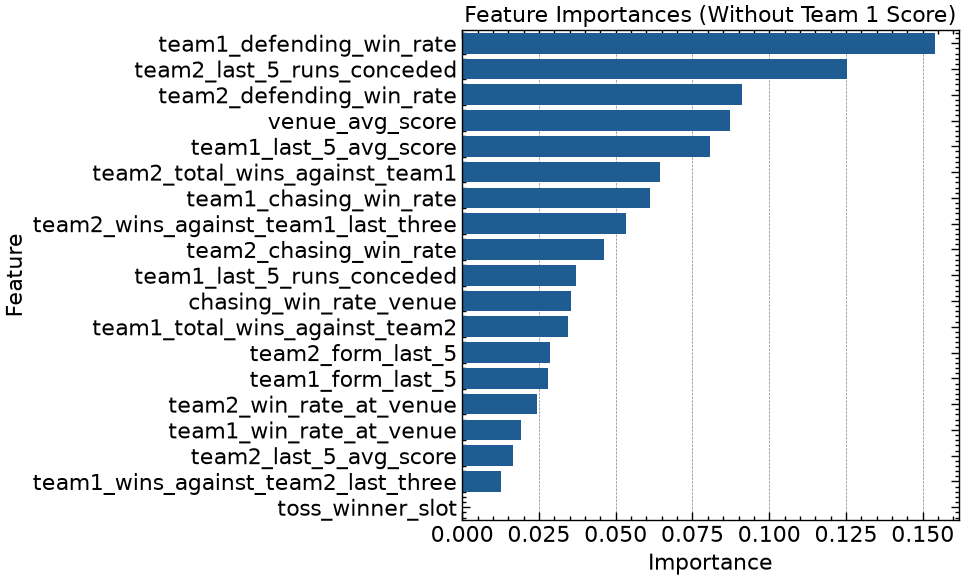

In [16]:
best_model = joblib.load("../models/production/no_score/best_model.pkl")

model = best_model.named_steps["classifier"]
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importances (Without Team 1 Score)")
plt.tight_layout()
plt.show()

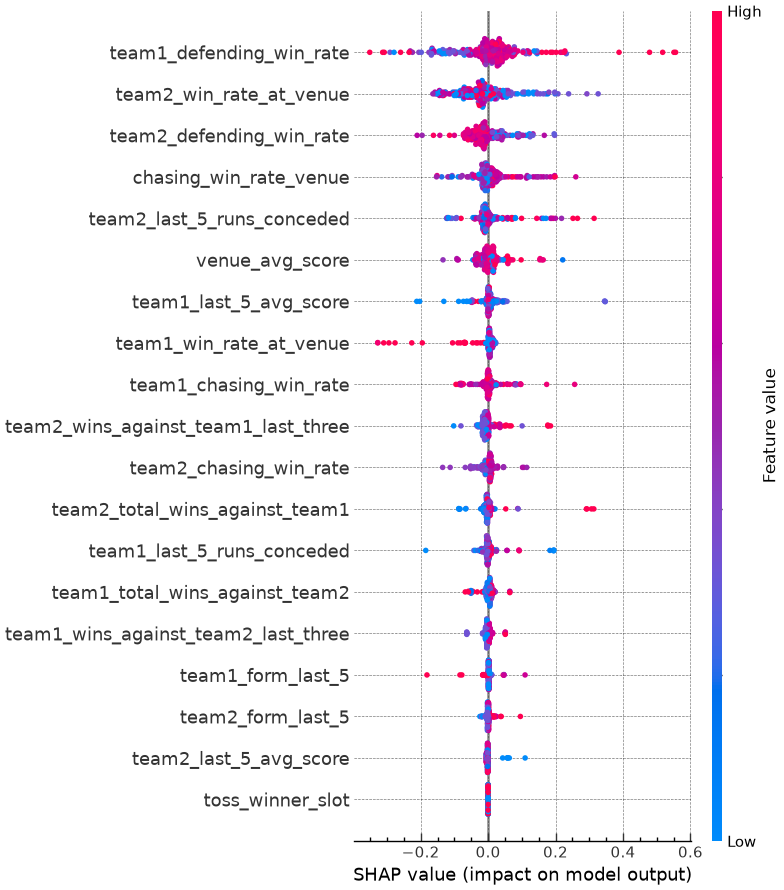

In [24]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values[:, :,  1],
    X_test,
    feature_names = X_test.columns
)

In [28]:
X_test = joblib.load("../data/splits/with_score/X_test.pkl")
features = X_test.columns.tolist()


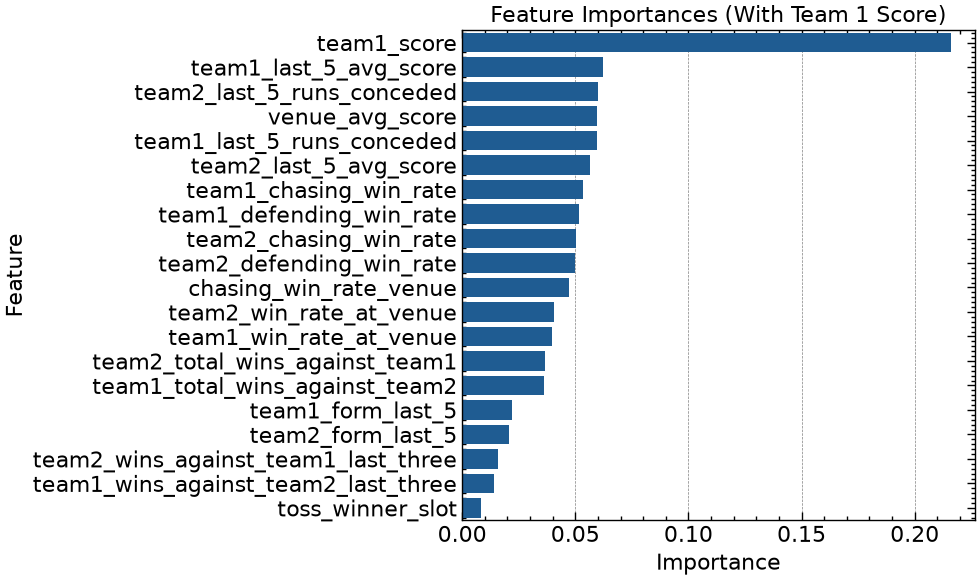

In [29]:
best_model = joblib.load("../models/production/with_score/best_model.pkl")

model = best_model.named_steps["classifier"]
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importances (With Team 1 Score)")
plt.tight_layout()
plt.show()

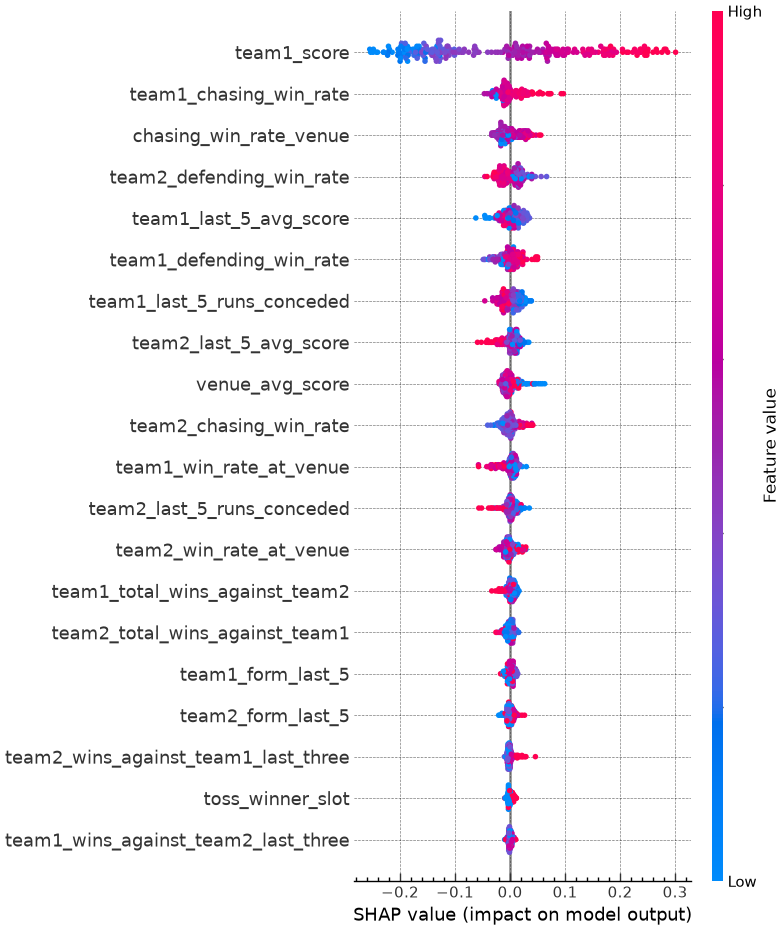

In [30]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values[:, :,  1],
    X_test,
    feature_names = X_test.columns
)